# EE344 Cardiovascular Risk Prediction - Group 3

## Project Overview
This notebook addresses the project proposal feedback by explicitly defining:
- **Explicit Preprocessing & Leakage Control:** Pipelines for categorical encoding (One-Hot), scaling (RobustScaler for outliers), and feature selection inside CV folds.
- **Strong Baselines & Model Diversity:** Added Gradient Boosting with explicit hyperparameter grids.
- **Rigorous Evaluation:** 5-fold Stratified CV, 80/20 train/test split, macro-F1 reporting for classification, and Dummy baseline (mean prediction) for regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and Pipelines
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, KFold, GridSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, f_regression

# Models
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier

# Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, f1_score, classification_report

## 1. Data Loading & Initial Setup

In [3]:
# Load dataset
df = pd.read_csv('cardiovascular_risk_dataset 2.csv')

# Drop ID column as it's not a feature
if 'Patient_ID' in df.columns:
    df = df.drop(columns=['Patient_ID'])

# Display basic info
display(df.head())
display(df.info())

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               5500 non-null   int64  
 1   bmi                               5500 non-null   float64
 2   systolic_bp                       5500 non-null   int64  
 3   diastolic_bp                      5500 non-null   int64  
 4   cholesterol_mg_dl                 5500 non-null   int64  
 5   resting_heart_rate                5500 non-null   int64  
 6   smoking_status                    5500 non-null   object 
 7   daily_steps                       5500 non-null   int64  
 8   stress_level                      5500 non-null   int64  
 9   physical_activity_hours_per_week  5500 non-null   float64
 10  sleep_hours                       5500 non-null   float64
 11  family_history_heart_disease      5500 non-null   object 
 12  diet_q

None

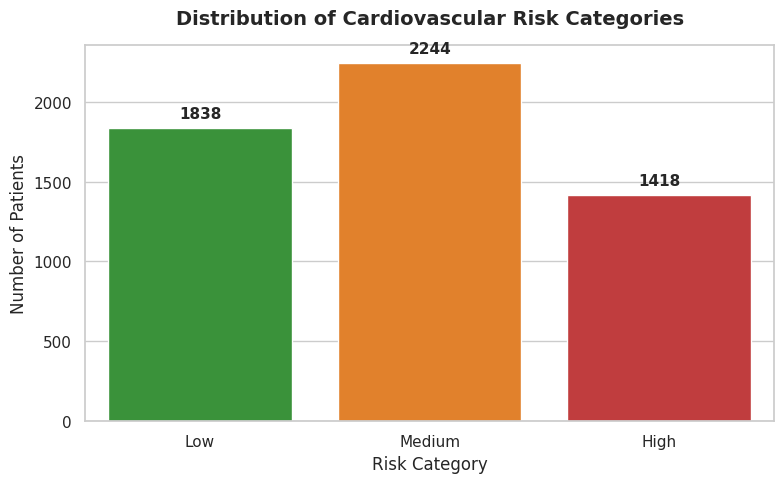

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for the report
sns.set_theme(style="whitegrid")

# Create a figure
plt.figure(figsize=(8, 5))

# Plot the distribution with a custom color palette
# Ordering logically: Low -> Medium -> High
ax = sns.countplot(
    data=df,
    x='risk_category',
    order=['Low', 'Medium', 'High'],
    palette={'Low': '#2ca02c', 'Medium': '#ff7f0e', 'High': '#d62728'},
    hue='risk_category', # Assigned to hue to avoid deprecation warnings
    legend=False
)

# Add titles and labels
plt.title('Distribution of Cardiovascular Risk Categories', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Risk Category', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Add exact count numbers on top of each bar
for p in ax.patches:
    height = p.get_height()
    # Skip if height is NaN (can happen with empty categories)
    if pd.notnull(height) and height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

# Display the plot
plt.tight_layout()
plt.show()


/tmp/ipykernel_363/3007096753.py:19: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[num_cols].hist(ax=ax, bins=25, color='steelblue', edgecolor='black', grid=False)


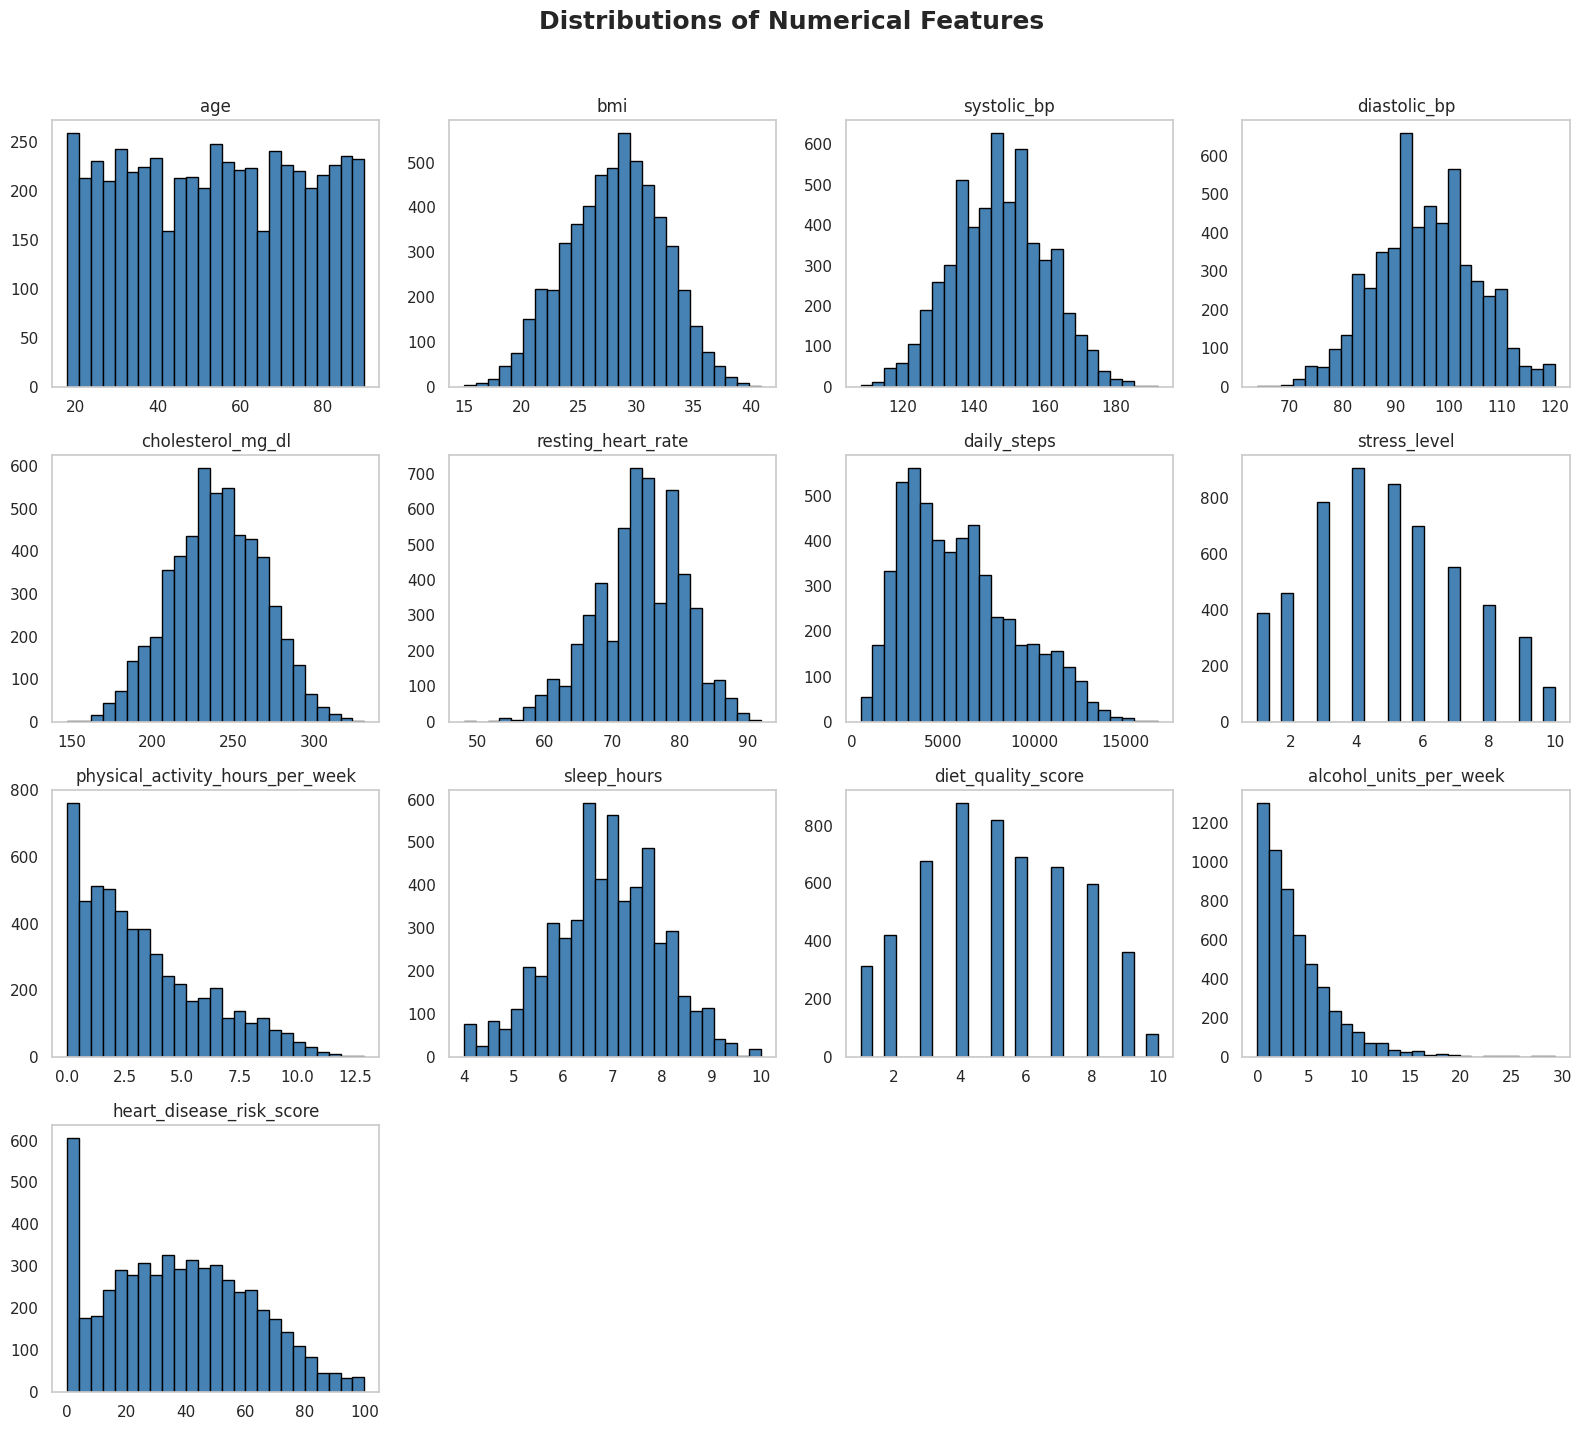

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn theme for professional looking plots
sns.set_theme(style="whitegrid")

# 1. Isolate numerical columns (excluding Patient_ID if it's still in the dataframe)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Patient_ID' in num_cols:
    num_cols.remove('Patient_ID')

# 2. Plot Histograms in a grid
# We use pandas built-in hist function wrapped in matplotlib for a clean grid
fig = plt.figure(figsize=(16, 14))
ax = fig.gca()

# Plot all numerical columns
df[num_cols].hist(ax=ax, bins=25, color='steelblue', edgecolor='black', grid=False)

# Add a main title
plt.suptitle('Distributions of Numerical Features', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


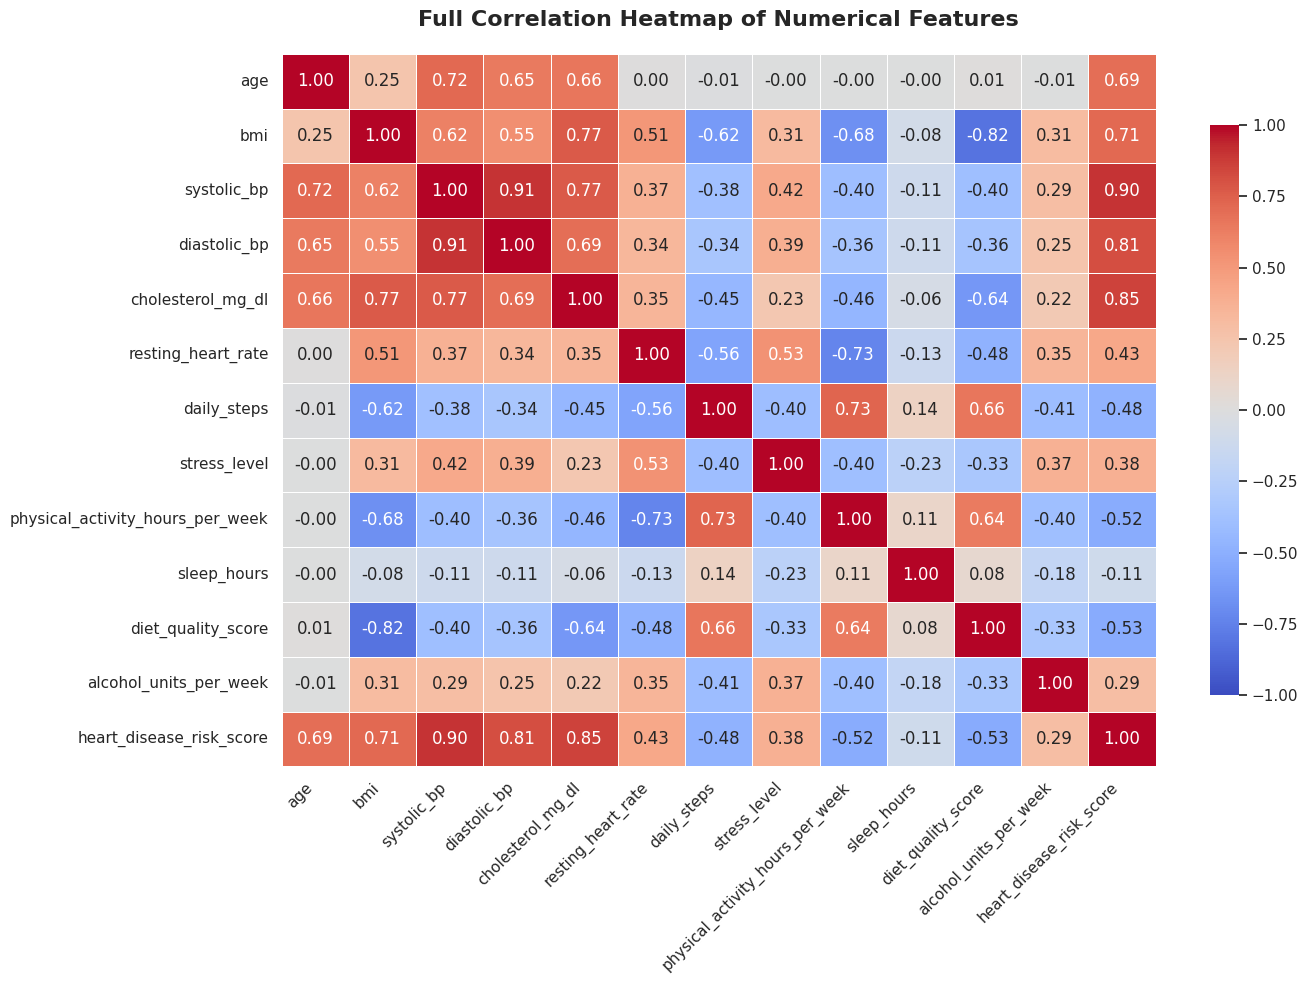

In [26]:
# 1. Calculate the correlation matrix
corr_matrix = df[num_cols].corr()

# 2. Set up the matplotlib figure
plt.figure(figsize=(14, 10))

# 3. Draw the full heatmap (removed the 'mask' argument)
sns.heatmap(
    corr_matrix,
    cmap='coolwarm', # Blue for negative, Red for positive correlation
    vmin=-1, vmax=1, # Fix the scale from -1 to 1
    annot=True,      # Show the actual correlation numbers
    fmt=".2f",       # Format numbers to 2 decimal places
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

# Add title and format
plt.title('Full Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 2. Preprocessing & Leakage Control Pipeline
To prevent data leakage, all preprocessing (scaling, encoding, feature selection) will be placed inside `sklearn.pipeline.Pipeline`.

**Choices made based on feedback:**
- **Scaling:** `RobustScaler` is used for numeric features because it uses median and IQR, making it robust against extreme outliers (e.g., highly elevated cholesterol or bp).
- **Categorical Encoding:** `OneHotEncoder` is used for nominal features like `smoking_status` and `family_history_heart_disease`.
- **Feature Selection:** Done *inside* the pipeline using `SelectKBest` to prevent optimistic evaluation metrics.

In [4]:
# Define Feature types
numeric_features = ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl',
                    'resting_heart_rate', 'daily_steps', 'stress_level',
                    'physical_activity_hours_per_week', 'sleep_hours',
                    'diet_quality_score', 'alcohol_units_per_week']
categorical_features = ['smoking_status', 'family_history_heart_disease']

# Define Target Variables
target_reg = 'heart_disease_risk_score'
target_clf = 'risk_category'

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features), # Handles outliers implicitly using IQR
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Separate Features and Targets
X = df.drop(columns=[target_reg, target_clf])
y_reg = df[target_reg]
y_clf = df[target_clf]

# 80/20 Train-Test Splits
# We split separately because classification needs stratification
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Regression Training shape: {X_train_reg.shape}")
print(f"Classification Training shape: {X_train_clf.shape}")

Regression Training shape: (4400, 14)
Classification Training shape: (4400, 14)


## 3. Task 1: Regression (0-100 Risk Score)
**Evaluation Setup:** 5-fold CV. Baseline = Predict Mean Risk Score.

In [15]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# 1. Simple Baseline: Predict Mean
dummy_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DummyRegressor(strategy='mean'))
])

# 2. Linear Baseline: Ridge Regression
ridge_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression, k='all')),
    ('regressor', Ridge())
])

# 3. Strong Tabular: Gradient Boosting
gb_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# 4. Random Forest
rf_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Model Dictionary for evaluation
reg_models = {
    "Dummy Baseline (Mean)": dummy_reg,
    "Ridge Regression": ridge_reg,
    "Gradient Boosting": gb_reg,
    "Random Forest": rf_reg
}

# Evaluate across folds
results_reg = []
for name, model in reg_models.items():
    cv_results = cross_validate(model, X_train_reg, y_train_reg, cv=cv_reg,
                                scoring=('neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'),
                                return_train_score=False)
    rmse = -cv_results['test_neg_root_mean_squared_error']
    r2 = cv_results['test_r2']
    results_reg.append({
        "Model": name,
        "RMSE (Mean ± Std)": f"{rmse.mean():.3f} ± {rmse.std():.3f}",
        "R² (Mean ± Std)": f"{r2.mean():.3f} ± {r2.std():.3f}"
    })

reg_results_df = pd.DataFrame(results_reg)
display(reg_results_df)

,Model,RMSE (Mean ± Std),R² (Mean ± Std)
0,Dummy Baseline (Mean),24.297 ± 0.538,-0.001 ± 0.000
1,Ridge Regression,4.353 ± 0.077,0.968 ± 0.001
2,Gradient Boosting,4.244 ± 0.124,0.969 ± 0.003
3,Random Forest,4.846 ± 0.165,0.960 ± 0.004


### 3.1 Hyperparameter Tuning for Gradient Boosting Regressor
Specifying explicit grid as requested: `depth`, `learning_rate`, `n_estimators`, `min_samples_leaf`.

In [6]:
param_grid_gb_reg = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.01, 0.1],
    'regressor__max_depth': [3, 5, 7],
    'regressor__min_samples_leaf': [1, 5]
}

grid_search_reg = GridSearchCV(gb_reg, param_grid_gb_reg, cv=cv_reg,
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search_reg.fit(X_train_reg, y_train_reg)

print("Best Parameters:", grid_search_reg.best_params_)
print(f"Best CV RMSE: {-grid_search_reg.best_score_:.3f}")

Best Parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 200}
Best CV RMSE: 3.668


## 4. Task 2: Classification (Low/Medium/High Risk)
**Evaluation Setup:** 5-fold Stratified CV. Reporting Macro-F1 and Accuracy.

In [14]:
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. Simple Baseline: Predict Majority Class
dummy_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='prior'))
])

# 2. Linear Baseline: Logistic Regression
log_reg_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k='all')),
    ('classifier', LogisticRegression(max_iter=1000))
])

# 3. Strong Tabular: Gradient Boosting Classifier
gb_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# 4. Random Forest
rf_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Evaluate Models
clf_models = {
    "Dummy Baseline (Majority)": dummy_clf,
    "Logistic Regression": log_reg_clf,
    "Gradient Boosting": gb_clf,
    "Random Forest": rf_clf
}

results_clf = []
for name, model in clf_models.items():
    cv_results = cross_validate(model, X_train_clf, y_train_clf, cv=cv_clf,
                                scoring=('accuracy', 'f1_macro'),
                                return_train_score=False)
    acc = cv_results['test_accuracy']
    f1 = cv_results['test_f1_macro']
    results_clf.append({
        "Model": name,
        "Accuracy (Mean ± Std)": f"{acc.mean():.3f} ± {acc.std():.3f}",
        "Macro-F1 (Mean ± Std)": f"{f1.mean():.3f} ± {f1.std():.3f}"
    })

clf_results_df = pd.DataFrame(results_clf)
display(clf_results_df)

,Model,Accuracy (Mean ± Std),Macro-F1 (Mean ± Std)
0,Dummy Baseline (Majority),0.408 ± 0.000,0.193 ± 0.000
1,Logistic Regression,0.935 ± 0.012,0.936 ± 0.012
2,Gradient Boosting,0.908 ± 0.009,0.910 ± 0.009
3,Random Forest,0.886 ± 0.011,0.888 ± 0.012


### 4.1 Hyperparameter Tuning for Gradient Boosting Classifier
Specifying tuning grid for classification as well.

In [8]:
param_grid_gb_clf = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__max_depth': [3, 5],
    'classifier__min_samples_leaf': [1, 5]
}

grid_search_clf = GridSearchCV(gb_clf, param_grid_gb_clf, cv=cv_clf,
                               scoring='f1_macro', n_jobs=-1)
grid_search_clf.fit(X_train_clf, y_train_clf)

print("Best Parameters:", grid_search_clf.best_params_)
print(f"Best CV Macro-F1: {grid_search_clf.best_score_:.3f}")

Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
Best CV Macro-F1: 0.918


## 5. Final Evaluation on Held-Out Test Set
Using the best estimators found from GridSearchCV.

In [ ]:
print("=== DYNAMIC FINAL EVALUATION ===\n")

# ---------------------------------------------------------
# 1. Regression: Select and Test Best Model
# ---------------------------------------------------------
# Parse CV scores
reg_results_df['Mean_RMSE'] = reg_results_df['RMSE (Mean ± Std)'].apply(lambda x: float(x.split(' ± ')[0]))
best_default_reg_row = reg_results_df.loc[reg_results_df['Mean_RMSE'].idxmin()]
tuned_reg_rmse = -grid_search_reg.best_score_

print("--- Task 1: Regression (Risk Score 0-100) ---")
if tuned_reg_rmse < best_default_reg_row['Mean_RMSE']:
    print(f"🏆 Winning Model: Tuned Gradient Boosting (CV RMSE: {tuned_reg_rmse:.3f})")
    best_reg_model = grid_search_reg.best_estimator_
else:
    print(f"🏆 Winning Model: {best_default_reg_row['Model']} (CV RMSE: {best_default_reg_row['Mean_RMSE']:.3f})")
    best_reg_model = reg_models[best_default_reg_row['Model']]
    best_reg_model.fit(X_train_reg, y_train_reg) # Retrain baseline on full training set

# Evaluate on Test Set
y_pred_reg = best_reg_model.predict(X_test_reg)
print(f"Final Test RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.3f}")
print(f"Final Test R²:   {r2_score(y_test_reg, y_pred_reg):.3f}\n")


# ---------------------------------------------------------
# 2. Classification: Select and Test Best Model
# ---------------------------------------------------------
# Parse CV scores
clf_results_df['Mean_F1'] = clf_results_df['Macro-F1 (Mean ± Std)'].apply(lambda x: float(x.split(' ± ')[0]))
best_default_clf_row = clf_results_df.loc[clf_results_df['Mean_F1'].idxmax()]
tuned_clf_f1 = grid_search_clf.best_score_

print("--- Task 2: Classification (Low/Medium/High) ---")
if tuned_clf_f1 > best_default_clf_row['Mean_F1']:
    print(f"Winning Model: Tuned Gradient Boosting (CV Macro-F1: {tuned_clf_f1:.3f})")
    best_clf_model = grid_search_clf.best_estimator_
else:
    print(f"Winning Model: {best_default_clf_row['Model']} (CV Macro-F1: {best_default_clf_row['Mean_F1']:.3f})")
    best_clf_model = clf_models[best_default_clf_row['Model']]
    best_clf_model.fit(X_train_clf, y_train_clf) # Retrain baseline on full training set

# Evaluate on Test Set
y_pred_clf = best_clf_model.predict(X_test_clf)
print("Final Test Classification Report:")
print(classification_report(y_test_clf, y_pred_clf))


=== DYNAMIC FINAL EVALUATION ===

--- Task 1: Regression (Risk Score 0-100) ---
🏆 Winning Model: Tuned Gradient Boosting (CV RMSE: 3.668)
Final Test RMSE: 3.506
Final Test R²:   0.979

--- Task 2: Classification (Low/Medium/High) ---
🏆 Winning Model: Logistic Regression (CV Macro-F1: 0.936)
Final Test Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.93      0.95       284
         Low       0.95      0.94      0.94       367
      Medium       0.91      0.94      0.92       449

    accuracy                           0.94      1100
   macro avg       0.94      0.94      0.94      1100
weighted avg       0.94      0.94      0.94      1100



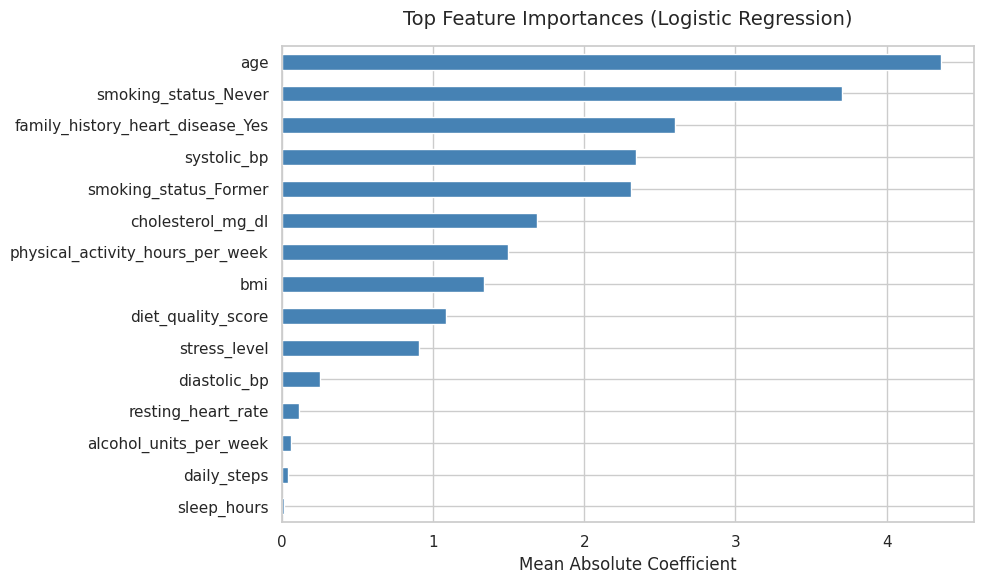

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Extract the classifier and preprocessor
classifier = best_clf_model.named_steps['classifier']
preprocessor = best_clf_model.named_steps['preprocessor']

# 2. Get the initial feature names out of the preprocessor
feature_names = preprocessor.get_feature_names_out()

# 3. Handle Feature Selection (SelectKBest) if it exists in the pipeline
if 'feature_selection' in best_clf_model.named_steps:
    selector = best_clf_model.named_steps['feature_selection']
    # Get the boolean mask of which features were actually kept
    selected_mask = selector.get_support()
    # Filter the feature names to only the ones passed to the classifier
    feature_names = feature_names[selected_mask]

# 4. Determine feature importances based on classifier type
if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    title_metric = 'Gini Importance'
elif hasattr(classifier, 'coef_'):
    # For Logistic Regression, use the mean of the absolute coefficients across classes
    importances = np.mean(np.abs(classifier.coef_), axis=0)
    title_metric = 'Mean Absolute Coefficient'
else:
    print("Classifier does not have feature importances or coefficients.")
    importances = np.array([])

# 5. Clean up feature names for the plot (optional, removes "num__" and "cat__" prefixes)
clean_names = [name.split('__')[-1] for name in feature_names]

# 6. Plot only if importances are available
if len(importances) > 0:
    plt.figure(figsize=(10, 6))
    feat_importances = pd.Series(importances, index=clean_names).sort_values(ascending=True)

    # Plot top 15 features
    feat_importances.tail(15).plot(kind='barh', color='steelblue')

    plt.title(f'Top Feature Importances ({best_default_clf_row["Model"]})', fontsize=14, pad=15)
    plt.xlabel(title_metric, fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot feature importances: No importances found for the selected classifier.")


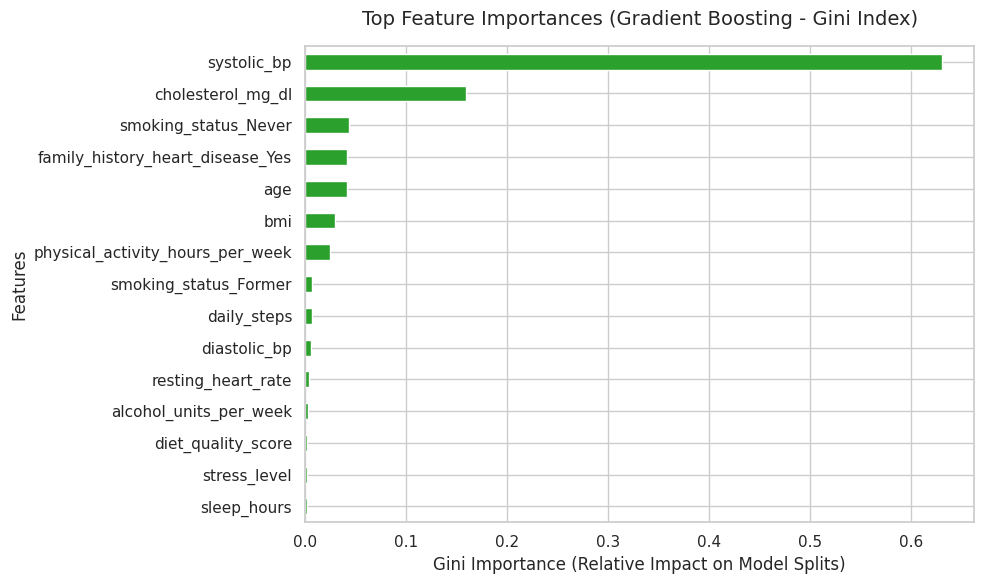

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Force the selection of the Tuned Gradient Boosting model from your GridSearchCV
gb_model = grid_search_clf.best_estimator_

# 2. Extract the classifier and preprocessor steps
classifier = gb_model.named_steps['classifier']
preprocessor = gb_model.named_steps['preprocessor']

# 3. Get the initial feature names out of the preprocessor
feature_names = preprocessor.get_feature_names_out()

# 4. Handle Feature Selection (SelectKBest) if it exists in the pipeline
if 'feature_selection' in gb_model.named_steps:
    selector = gb_model.named_steps['feature_selection']
    selected_mask = selector.get_support()
    feature_names = feature_names[selected_mask]

# 5. Extract Gini Feature Importances (Tree-based metric)
if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
else:
    print("Error: The selected model is not a tree-based model.")
    importances = np.array([])

# 6. Clean up feature names for the plot (Removes "num__" and "cat__" prefixes)
clean_names = [name.split('__')[-1] for name in feature_names]

# 7. Plot the results
if len(importances) > 0:
    plt.figure(figsize=(10, 6))

    # Create a pandas series, sort it, and plot the top 15
    feat_importances = pd.Series(importances, index=clean_names).sort_values(ascending=True)
    feat_importances.tail(15).plot(kind='barh', color='#2ca02c') # Using a nice green color

    # Format the chart for your report
    plt.title('Top Feature Importances (Gradient Boosting - Gini Index)', fontsize=14, pad=15)
    plt.xlabel('Gini Importance (Relative Impact on Model Splits)', fontsize=12)
    plt.ylabel('Features', fontsize=12)

    plt.tight_layout()
    plt.show()
